# EMStats Demo

This notebook demonstrates the functionalities of the `emstats` module in `auralab`, including:
- Exponential Moving Average (EMA)
- Moving Variance and Standard Deviation
- Z-Score (Standardized Score)
- Moving Covariance

**Note:** This notebook requires a CUDA-enabled GPU.

In [1]:
import torch
import matplotlib.pyplot as plt
from auralab.emstats import emstats

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type != 'cuda':
    print("Warning: auralab.ema currently requires CUDA. This notebook might fail on CPU.")

Using device: cuda


## 1. Generate Synthetic Data (Brownian Motion)
We generate a non-stationary signal using a random walk (Brownian motion) to demonstrate how `emstats` adapts to changing distributions.

In [2]:
torch.manual_seed(42)
n_steps = 1000
t = torch.arange(n_steps, device=device).float()

# Generate random steps
steps = torch.randn(n_steps, device=device)
# Cumulative sum to create a random walk
x = torch.cumsum(steps, dim=0) + 10

# Alpha for EMA (smoothing factor)
alpha = torch.tensor(0.05, device=device)

## 2. Exponential Moving Average (EMA)
Compute the moving average using `emstats`. The EMA should track the trend of the random walk.

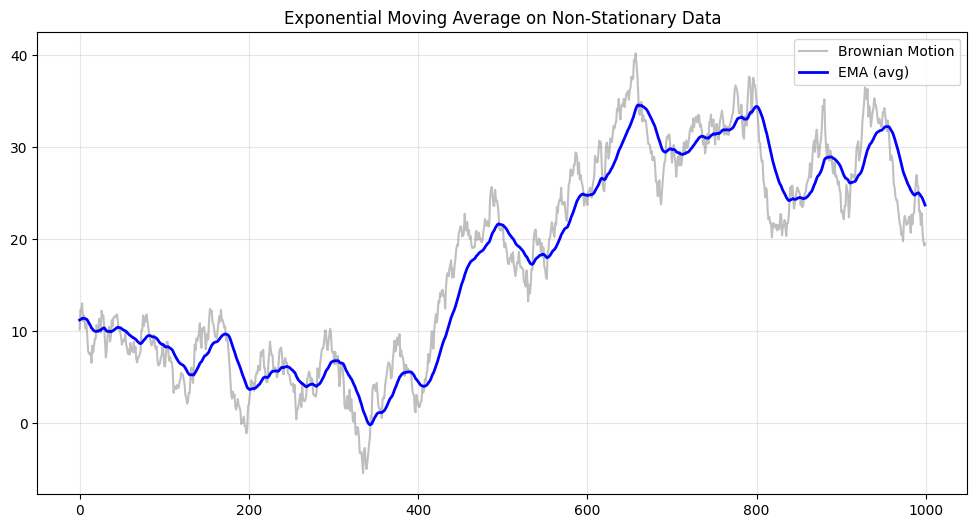

In [3]:
stats = emstats(x, alpha)
avg = stats.avg

# Move to CPU for plotting
t_cpu = t.cpu()
x_cpu = x.cpu()
avg_cpu = avg.cpu()

plt.figure(figsize=(12, 6))
plt.plot(t_cpu, x_cpu, label='Brownian Motion', alpha=0.5, color='gray')
plt.plot(t_cpu, avg_cpu, label='EMA (avg)', linewidth=2, color='blue')
plt.legend()
plt.title("Exponential Moving Average on Non-Stationary Data")
plt.grid(True, alpha=0.3)
plt.show()

## 3. Moving Variance and Standard Deviation
Visualize the local variability of the random walk.

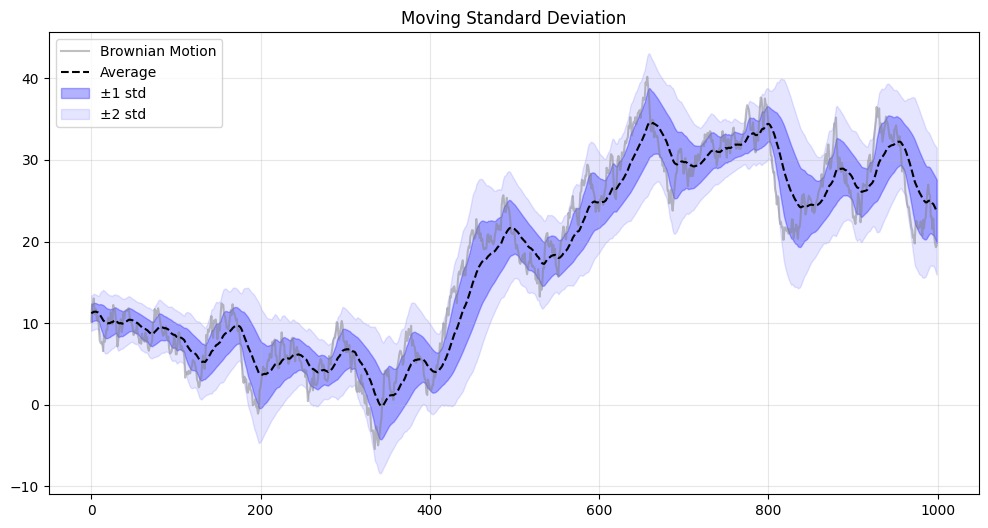

In [4]:
std = stats.std
std_cpu = std.cpu()

plt.figure(figsize=(12, 6))
plt.plot(t_cpu, x_cpu, label='Brownian Motion', alpha=0.5, color='gray')
plt.plot(t_cpu, avg_cpu, label='Average', color='black', linestyle='--')
plt.fill_between(t_cpu, avg_cpu - std_cpu, avg_cpu + std_cpu, alpha=0.3, color='blue', label='±1 std')
plt.fill_between(t_cpu, avg_cpu - 2*std_cpu, avg_cpu + 2*std_cpu, alpha=0.1, color='blue', label='±2 std')
plt.legend()
plt.title("Moving Standard Deviation")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Z-Score (Anomaly Detection)
The Z-score normalizes the data relative to the local mean and standard deviation.

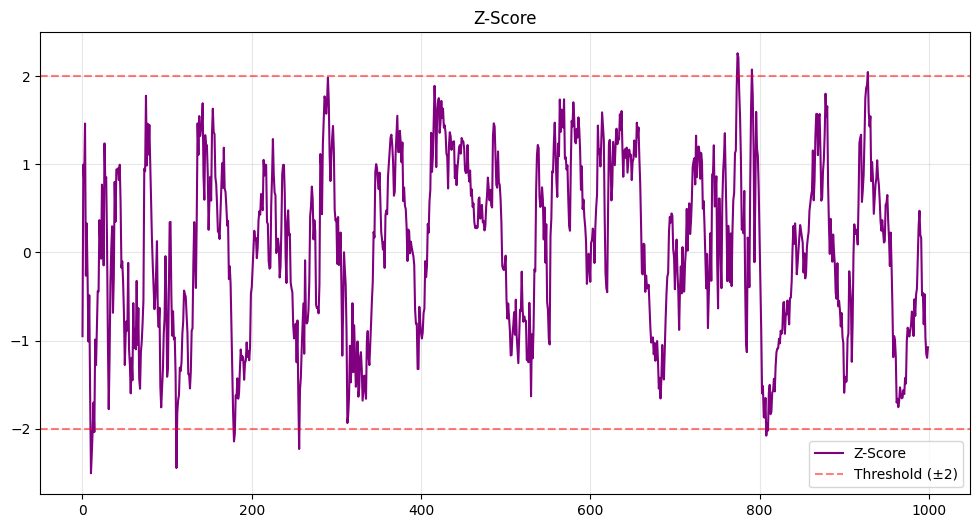

In [5]:
z = stats.zscore
z_cpu = z.cpu()

plt.figure(figsize=(12, 6))
plt.plot(t_cpu, z_cpu, label='Z-Score', color='purple')
plt.axhline(2, color='red', linestyle='--', alpha=0.5, label='Threshold (±2)')
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.title("Z-Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Moving Covariance
Compute the covariance between two correlated random walks.

torch.Size([1000, 1])


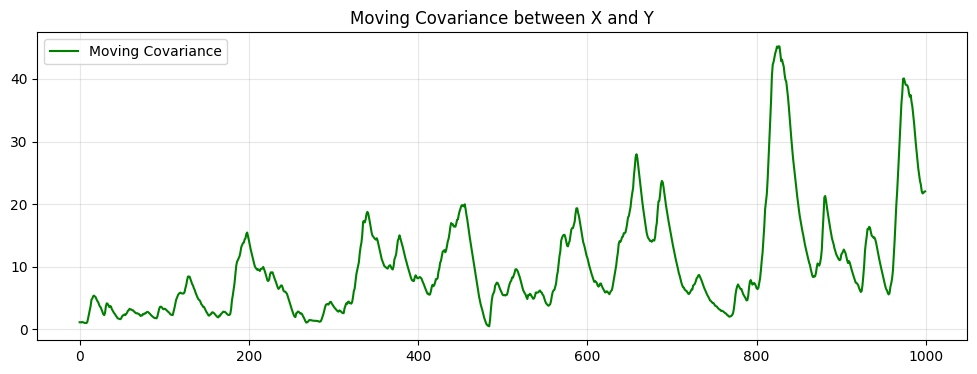

In [6]:
# Generate a second signal correlated with x
# y = 0.8 * x + noise
noise = torch.randn_like(x) * 0.75
y = x + torch.cumsum(noise, dim=0)    

# Stack x and y into a single tensor of shape (T, 2)
xy = torch.stack([x, y], dim=1)

# Compute stats for the combined signal
stats_xy = emstats(xy, alpha, dim=0)

# Compute covariance matrix
# dim_c=1 corresponds to the feature dimension (x and y)
# By default, diagonal=False, so it returns only off-diagonal elements (covariance)
cov_matrix = stats_xy.cov(dim_c=1)

print(cov_matrix.shape)

# Extract covariance between x and y
# cov_matrix returns flattened strictly upper triangular part: (cov_xy)
# shape: (T, 1)
# We want the element at index 0
cov_xy = cov_matrix[:, 0]

# Move to CPU for plotting
cov_cpu = cov_xy.cpu()
y_cpu = y.cpu()

plt.figure(figsize=(12, 4))
plt.plot(t_cpu, cov_cpu, label='Moving Covariance', color='green')
plt.title("Moving Covariance between X and Y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Moving Correlation
Compute the moving correlation between two signals. We'll generate a second signal that is correlated with the first one to demonstrate this.

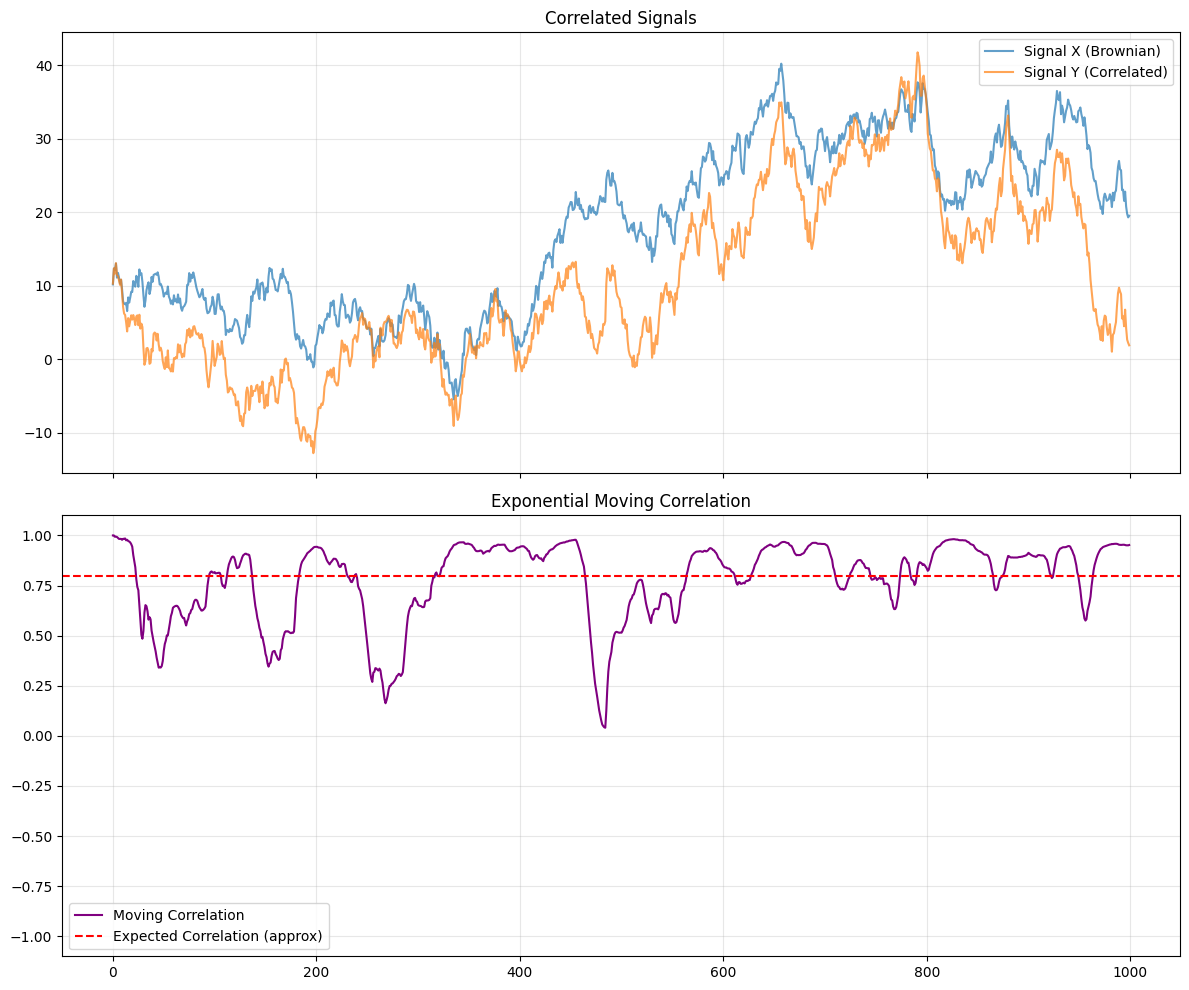

In [7]:
# Compute correlation matrix
# dim_c=1 corresponds to the feature dimension (x and y)
# By default, diagonal=False, so it returns only off-diagonal elements
corr_matrix = stats_xy.corr(dim_c=1)

# Extract correlation between x and y
# corr_matrix returns flattened strictly upper triangular part: (corr_xy)
# shape: (T, 1)
# We want the element at index 0
rho_xy = corr_matrix[:, 0]

# Move to CPU for plotting
rho_cpu = rho_xy.cpu()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(t_cpu, x_cpu, label='Signal X (Brownian)', alpha=0.7)
ax1.plot(t_cpu, y_cpu, label='Signal Y (Correlated)', alpha=0.7)
ax1.set_title("Correlated Signals")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(t_cpu, rho_cpu, label='Moving Correlation', color='purple')
ax2.axhline(0.8, color='red', linestyle='--', label='Expected Correlation (approx)')
ax2.set_title("Exponential Moving Correlation")
ax2.set_ylim(-1.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()